# Projekat: Segmentacija E-Commerce Kupaca i Narudzbina 

**Tema**: Nenadgledano ucenje - Klasterizacija

**Dataset**: [E-Commerce Sales Dataset (Amazon Sale Report)](https://www.kaggle.com/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data)


## Definicija problema i ucitavanje podataka

### Cilj: Primenom algoritama nenadgledanog ucenja izvrsiti segmentaciju Amazon e-commerce narudzbina na osnovu njihovih karakteristika: **iznosa**, **kolicine**, **kategorije** **proizvoda** i **tipa kupca** (**B2B/B2C**).

### **Krajnji cilj** je otkriti prirodne grupe narudzbina koje mogu pomoci u boljem razumevanju kupackih obrazaca na Amazon India platformi.

### Ucitavanje biblioteka i skupa podataka.

In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

import warnings
warnings.filterwarnings("ignore")

In [188]:
df = pd.read_csv('data/amazon_sale_report.csv')

df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


## Deskriptivna analiza i priprema podataka

### Istrazivanje dataseta

In [189]:
print(f"Shape: {df.shape}")

print("\nKolone(Datatypes):")

for i,col_name in enumerate(df.columns, 1):
    print(f"{i}:{col_name}({df[col_name].dtypes})")

print(f"\nTipovi podataka:\n{df.dtypes}")

print(f"\nMissing vrednosti:\n{df.isnull().sum()}")

print(f"\nStatistike:\n{df.describe()}")

Shape: (128975, 24)

Kolone(Datatypes):
1:index(int64)
2:Order ID(str)
3:Date(str)
4:Status(str)
5:Fulfilment(str)
6:Sales Channel (str)
7:ship-service-level(str)
8:Style(str)
9:SKU(str)
10:Category(str)
11:Size(str)
12:ASIN(str)
13:Courier Status(str)
14:Qty(int64)
15:currency(str)
16:Amount(float64)
17:ship-city(str)
18:ship-state(str)
19:ship-postal-code(float64)
20:ship-country(str)
21:promotion-ids(str)
22:B2B(bool)
23:fulfilled-by(str)
24:Unnamed: 22(object)

Tipovi podataka:
index                   int64
Order ID                  str
Date                      str
Status                    str
Fulfilment                str
Sales Channel             str
ship-service-level        str
Style                     str
SKU                       str
Category                  str
Size                      str
ASIN                      str
Courier Status            str
Qty                     int64
currency                  str
Amount                float64
ship-city                 str
shi

In [190]:
missing_percent = df.isnull().sum() / len(df) *100

print("Null vrednosti u % po koloni: \n", missing_percent[missing_percent>0])
print("Total NaN count: ", df.isnull().sum().sum())

Null vrednosti u % po koloni: 
 Courier Status       5.328164
currency             6.043807
Amount               6.043807
ship-city            0.025586
ship-state           0.025586
ship-postal-code     0.025586
ship-country         0.025586
promotion-ids       38.110487
fulfilled-by        69.546811
Unnamed: 22         38.030626
dtype: float64
Total NaN count:  210495


### Data cleanup

In [191]:
df = df.copy()

#### Brisanje beskorisnih kolona

In [192]:
df = df.drop(columns=[
    'Unnamed: 22',
    'fulfilled-by',
    'Order ID',
    'promotion-ids',
    'ASIN',
    'SKU',
    'index',
    'ship-country',
    'ship-postal-code',
    'currency'
])

df.shape

(128975, 14)

#### Otklanjanja duplikata i NaN

In [193]:
print(f'Duplikati: ', df.duplicated().sum())

df = df.drop_duplicates()

print(f'Duplikati: ', df.duplicated().sum())

df.shape

Duplikati:  2442
Duplikati:  0


(126533, 14)

In [194]:
# Otklananje 0 i NaN podataka
df = df[df['Amount'] > 0]
df = df[df['Qty'] > 0]
df = df.dropna(subset=['Amount', 'Qty'])

# Preimenovanje NaN podataka
df['Courier Status'] = df['Courier Status'].fillna('Cancelled', inplace=True)
df['ship-city'] = df['ship-city'].fillna('Unknown-city', inplace=True)
df['ship-state'] = df['ship-state'].fillna('Unknown-state', inplace=True)

print(f'Shape nakon ciscenja: {df.shape}')
print(f'\nPreostale NaN vrednosti:\n{df.isnull().sum()}')

Shape nakon ciscenja: (111878, 14)

Preostale NaN vrednosti:
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
Category              0
Size                  0
Courier Status        0
Qty                   0
Amount                0
ship-city             0
ship-state            0
B2B                   0
dtype: int64


### Exploratory Data Analysis (EDA)

#### Amount

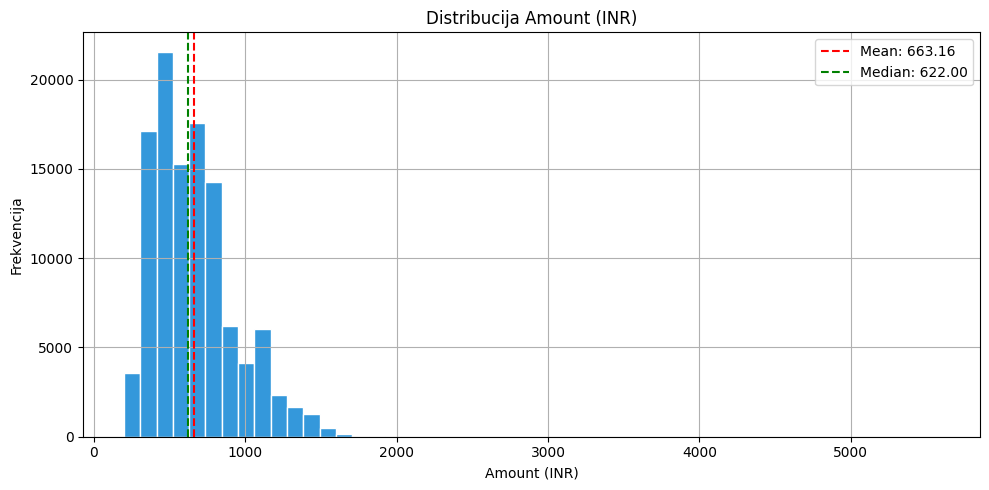

In [195]:
plt.figure(figsize=(10, 5))

df['Amount'].dropna().hist(bins=50, color='#3498db', edgecolor='white')

plt.title('Distribucija Amount (INR)')
plt.xlabel('Amount (INR)')
plt.ylabel('Frekvencija')
plt.tight_layout()
plt.axvline(df['Amount'].mean(), color='red', linestyle='--',
            label=f'Mean: {df["Amount"].mean():.2f}')
plt.axvline(df['Amount'].median(), color='green', linestyle='--',
            label=f'Median: {df["Amount"].median():.2f}')
plt.legend()
plt.show()

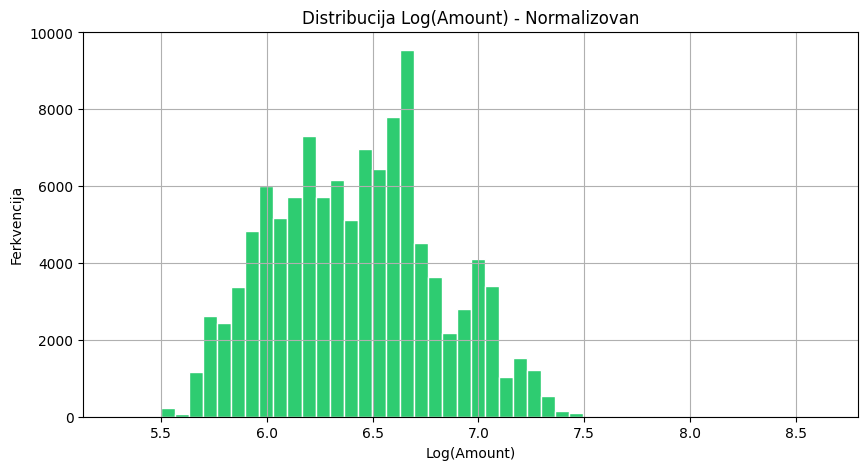

In [196]:
df['Amount_log'] = np.log1p(df['Amount'])

plt.figure(figsize=(10, 5))
df['Amount_log'].hist(bins=50, color='#2ecc71', edgecolor="white")
plt.title('Distribucija Log(Amount) - Normalizovan')
plt.xlabel('Log(Amount)')
plt.ylabel('Ferkvencija')
plt.show()

#### Qty

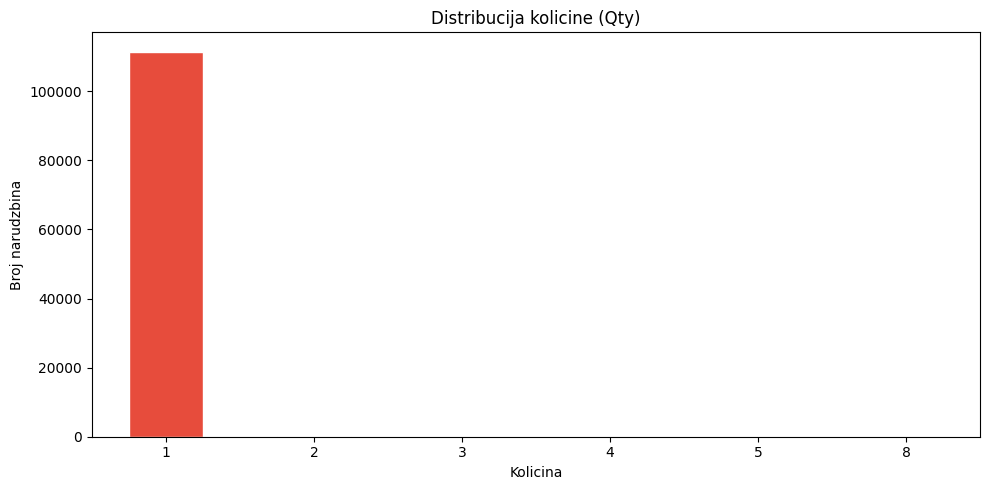

In [197]:
plt.figure(figsize=(10, 5))

df['Qty'].value_counts().sort_values(ascending=False).plot(kind='bar', color='#e74c3c', edgecolor="white")

plt.title('Distribucija kolicine (Qty)')
plt.xlabel('Kolicina')
plt.xticks(rotation=0)
plt.ylabel('Broj narudzbina')
plt.tight_layout()
plt.show()

In [198]:
print(df['Qty'].value_counts().sort_index())
print(f"\nProcenat Qty=1: {(df['Qty']==1).sum() / len(df) * 100:.1f}%")

Qty
1    111501
2       335
3        31
4         8
5         2
8         1
Name: count, dtype: int64

Procenat Qty=1: 99.7%


In [199]:
df['Revenue'] = df['Amount'] * df['Qty']

print(df[df['Qty'] > 1][['Amount', 'Qty', 'Revenue']].head(10))

      Amount  Qty  Revenue
265   2130.0    2   4260.0
647   2224.0    2   4448.0
1018  1518.0    2   3036.0
1696  1308.0    2   2616.0
2107  1128.0    3   3384.0
2185   972.0    2   1944.0
2189   864.0    2   1728.0
2583   990.0    2   1980.0
3289  2175.0    3   6525.0
5320   720.0    2   1440.0


#### Revenue

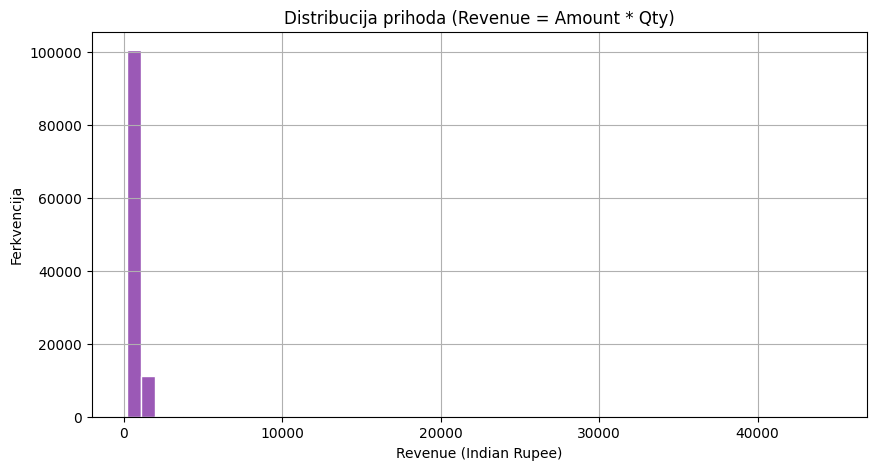

In [200]:
plt.figure(figsize=(10, 5))

df['Revenue'].hist(bins=50, color="#9b59b6", edgecolor="white")

plt.title('Distribucija prihoda (Revenue = Amount * Qty)')
plt.xlabel('Revenue (Indian Rupee)')
plt.ylabel('Ferkvencija')
plt.show()

#### Category

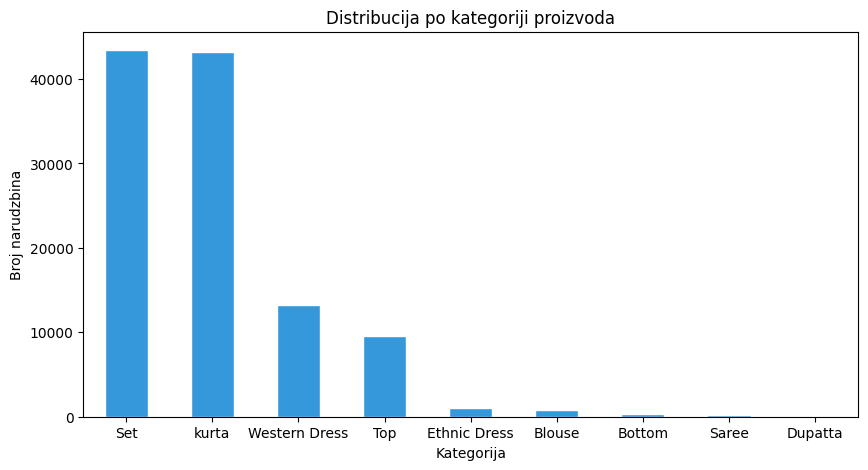

In [201]:
plt.figure(figsize=(10, 5))

df['Category'].value_counts().plot(kind='bar', color='#3498db', edgecolor='white')

plt.title('Distribucija po kategoriji proizvoda')
plt.xlabel('Kategorija')
plt.xticks(rotation=0)
plt.ylabel('Broj narudzbina')
plt.show()

#### Tip kupca (B2B/B2C)

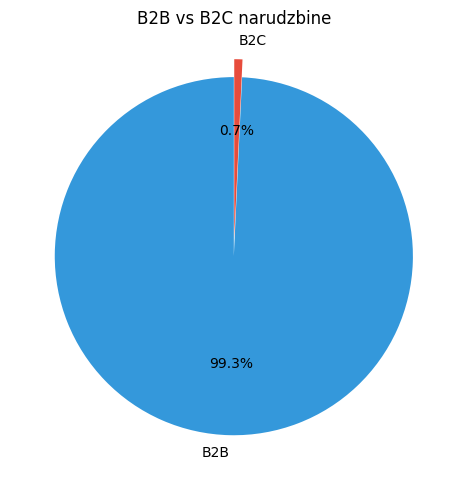

In [202]:
plt.figure(figsize=(10, 5))

b2b_count = df['B2B'].value_counts()
colors = ['#3498db', '#e74c3c']

plt.pie(b2b_count.values, labels=['B2B', 'B2C'], autopct='%1.1f%%', 
        colors=colors, startangle=90, explode=[0, 0.1])
plt.title('B2B vs B2C narudzbine')
plt.tight_layout()
plt.show()

### Feature Engineering

In [204]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter

print(df['Month'].value_counts().sort_index())
print(df['Day'].value_counts().sort_index())

Month
3      155
4    42339
5    36461
6    32923
Name: count, dtype: int64
Day
0    16109
1    16374
2    16079
3    14831
4    15340
5    16060
6    17085
Name: count, dtype: int64
